# QU-AI-GUARD — AI-Guarded Quantum Key Distribution

**Secure satellite-to-ground communication using real quantum BB84 key exchange, protected by a machine-learning guard.**

This notebook runs the full pipeline end-to-end on a single satellite pass:
1. **Simulate the orbit** — a LEO satellite passes over the Chennai ground station.
2. **Run real BB84 QKD** — Qiskit-Aer circuits with atmospheric noise (no cheat data).
3. **AI auto-tune** — a trained `LinkPredictor` picks the best QKD parameters for the pass.
4. **Catch Eve** — a trained `EveDetector` watches the QBER stream and raises the alarm.
5. **Show results** — secure key, QBER, alarm confidence, and the honest evaluation numbers.

> All data is simulated; the quantum layer is executed on a real quantum-circuit simulator.

## 0. Setup

In [1]:
from pathlib import Path
import sys
# Notebook lives in notebooks/; project root is one level up.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.orbit.geometry import GroundStation
from src.orbit.link import LinkModel
from src.quantum.bb84 import run_bb84_round
from src.quantum.attacks import EveAttack, run_attacked_sift
from src.quantum.params import QKDParams
from src.ai.link_predictor import LinkPredictor, link_features_from_pass
from src.ai.eve_detector import EveDetector
from src.ai.fusion import GuardEngine

GS = GroundStation(lat_deg=13.0827, lon_deg=80.2707, alt_m=10.0, name="Chennai-ISRO")
N_PHOTONS = 96
print("Setup OK")

Setup OK


## 1. Simulate a satellite pass

In [2]:
# Load a realistic pre-simulated pass (QKD-LEO, high link quality)
meta = pd.read_csv(ROOT / "data/orbits/passes_meta.csv")
best = meta[meta["satellite"] == "QKD-LEO"].sort_values("mean_link_q", ascending=False).iloc[0]
pass_df = pd.read_csv(ROOT / f"data/orbits/{best['pass_id']}.csv")
print(f"Pass {best['pass_id']} | {best['satellite']} | {len(pass_df)} samples "
      f"| max elevation {best['max_elev']:.1f} deg | link quality {best['mean_link_q']:.2f}")
pass_df[["t_sec", "elevation_deg", "link_quality"]].head()

Pass P0194 | QKD-LEO | 27 samples | max elevation 81.5 deg | link quality 0.85


,t_sec,elevation_deg,link_quality
0,1094.999981,16.987424,0.592787
1,1109.999980,19.200190,0.631879
2,1124.999980,21.671362,0.673461
3,1139.999980,24.456950,0.718119
4,1154.999980,27.627661,0.766541


## 2. Real BB84 key exchange over the pass

Mean QBER: 0.0760 | mean secure key rate: 1089 kbps


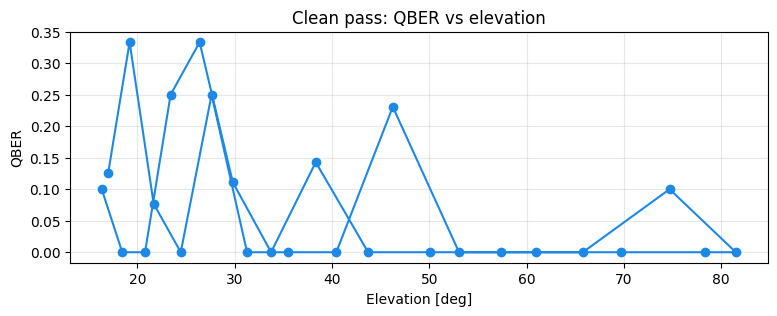

In [3]:
rng = np.random.default_rng(7)
link = LinkModel()
rows = []
for _, row in pass_df.iterrows():
    channel = link.channel_noise(row["elevation_deg"], row["mjd"], GS.lat_deg, GS.lon_deg, rng)
    round_ = run_bb84_round(N_PHOTONS, channel, QKDParams(), rng)
    rows.append({"elevation_deg": row["elevation_deg"], "link_quality": channel["link_quality"],
                 "qber": round_.qber, "secure_bps": round_.secure_key_bps,
                 "n_sifted": round_.n_sifted})
q = pd.DataFrame(rows)
print("Mean QBER:", f"{q['qber'].mean():.4f}", "| mean secure key rate:",
      f"{q['secure_bps'].mean()/1000:.0f} kbps")
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(q["elevation_deg"], q["qber"], "o-", color="#1e88e5")
ax.set_xlabel("Elevation [deg]"); ax.set_ylabel("QBER"); ax.set_title("Clean pass: QBER vs elevation")
ax.grid(alpha=0.3)
plt.show()

## 3. AI auto-tune: LinkPredictor recommends QKD parameters

In [4]:
lp = LinkPredictor.load(ROOT / "models/link_predictor.joblib")
feats = link_features_from_pass(pass_df, sat_idx=int(best["sat_idx"]))
best_cfg, pred_qber, pred_bps = lp.recommend(feats)
print("LinkPredictor recommends:", best_cfg)
print(f"Expected QBER {pred_qber:.3f} | expected secure rate {pred_bps/1000:.0f} kbps")
print("Fixed default:", QKDParams(), f"-> {QKDParams().as_array()}")

LinkPredictor recommends: QKDParams(mu=0.80, dark=300 Hz, eta=0.60, pZ=0.50)
Expected QBER 0.056 | expected secure rate 2093 kbps
Fixed default: QKDParams(mu=0.50, dark=100 Hz, eta=0.50, pZ=0.50) -> [  0.5 100.    0.5   0.5]


## 4. The GuardEngine: auto-tune + live Eve detection

In [5]:
det = EveDetector.load(ROOT / "models/eve_detector.joblib")
engine = GuardEngine(link_predictor=lp, eve_detector=det)
config = engine.start_pass(pass_df, sat_idx=int(best["sat_idx"]), auto_tune=True)
print("AI chose:", config)

verdicts = []
for i, (_, row) in enumerate(pass_df.iterrows()):
    channel = link.channel_noise(row["elevation_deg"], row["mjd"], GS.lat_deg, GS.lon_deg, rng)
    r = run_bb84_round(N_PHOTONS, channel, config, rng)
    frac_t = i / max(len(pass_df) - 1, 1)
    run_attacked_sift(r, EveAttack("none", 0.0), rng, frac_t=frac_t)
    v = engine.update(r.qber, r.secure_key_bps, r.raw_key_bps,
                      r.secure_key_hex, r.secure_key_bits, row["t_sec"],
                      mean_link_q=channel["link_quality"])
    verdicts.append(v)
print("Clean pass final verdict:", verdicts[-1].threat, f"| conf={verdicts[-1].confidence:.2f}")

AI chose: QKDParams(mu=0.80, dark=300 Hz, eta=0.60, pZ=0.50)


Clean pass final verdict: SECURE | conf=0.03


## 5. Eve attacks — does the guard catch her?

In [6]:
for eve_name, strength in [("intercept_resend", 0.6), ("pns", 0.6),
                             ("intermittent", 0.6)]:
    engine = GuardEngine(link_predictor=lp, eve_detector=det)
    engine.start_pass(pass_df, sat_idx=int(best["sat_idx"]), auto_tune=True)
    vs = []
    for i, (_, row) in enumerate(pass_df.iterrows()):
        channel = link.channel_noise(row["elevation_deg"], row["mjd"], GS.lat_deg, GS.lon_deg, rng)
        r = run_bb84_round(N_PHOTONS, channel, engine.current_config, rng)
        frac_t = i / max(len(pass_df) - 1, 1)
        run_attacked_sift(r, EveAttack(eve_name, strength), rng, frac_t=frac_t)
        v = engine.update(r.qber, r.secure_key_bps, r.raw_key_bps,
                          r.secure_key_hex, r.secure_key_bits, row["t_sec"],
                          mean_link_q=channel["link_quality"])
        vs.append(v)
    print(f"{eve_name:16s} strength {strength:.1f}: {vs[-1].threat} "
          f"| conf={vs[-1].confidence:.2f} | mean QBER {np.mean([v.qber for v in vs]):.3f}")

intercept_resend strength 0.6: INTRUSION | conf=1.00 | mean QBER 0.210


pns              strength 0.6: INTRUSION | conf=0.92 | mean QBER 0.072


intermittent     strength 0.6: INTRUSION | conf=1.00 | mean QBER 0.207


### What you are seeing
- **intercept-resend** and **intermittent** attacks raise QBER and the AI guard flags the session (INTRUSION).
- **PNS** (photon-number-splitting) at this strength barely perturbs QBER — it is *designed* to be stealthy.
  Real systems counter PNS with decoy states; that is why the detector is honest about it (see the eval report).

## 6. Honest evaluation summary (from the pipeline)

In [7]:
with open(ROOT / "results/reports/evaluation_report.md") as f:
    print(f.read())

# QU-AI-GUARD â€” Evaluation Report

## 1. AI auto-tune vs fixed QKD config
- Fixed config mean secure key rate: **770440.8 bps**
- AI-tuned mean secure key rate: **1273278.9 bps**
- Improvement: **+65.3%** (n = 12 held-out passes)

## 2. Eve detector (hold-out)
- AUC = **0.873**
- Precision = **0.986**, Recall = **0.453**, F1 = **0.621**
- False-alarm rate = **2.00%** at threshold 1.00
- Accuracy = **58.5%** (n_clean=50, n_attack=150)

## 3. Attack-strength sweep (intercept-resend)

| Strength | Detection rate | Mean QBER |
|---|---|---|
| 0.10 | 50% | 0.144 |
| 0.20 | 50% | 0.160 |
| 0.30 | 50% | 0.159 |
| 0.40 | 100% | 0.188 |
| 0.60 | 83% | 0.220 |
| 0.80 | 83% | 0.261 |
| 1.00 | 100% | 0.329 |

## 4. Detection by attack type (operating threshold)

| Attack | Pct detected | Mean alarm confidence |
|---|---|---|
| intercept_resend | 65% | 0.99 |
| intermittent | 68% | 0.99 |
| none | 2% | 0.20 |
| pns | 12% | 0.86 |

## 5. Figures
- `figures/key_rate_comparison.png`
- `figures/eve_d

## Done — see the Streamlit live demo and README for more.